In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("ChurnPredictionEDA") \
    .config("spark.driver.memory", "12g") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

In [ ]:
master_table_path = "data_final/master_feature_table_final.parquet"

print(f"Memuat data dari {master_table_path}...")
master_table_spark = spark.read.parquet(master_table_path)
master_table_spark.cache()

# print schema
print("Skema master_table:")
master_table_spark.printSchema()

# convert to Pandas DataFrame for visualization
print("\nMengonversi ke Pandas DataFrame")
master_table_pd = master_table_spark.toPandas()

# display data
display(master_table_pd.head())

Memuat data dari ../dataset/data/master_feature_table_final.parquet...
Skema master_table:
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- age_group: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- total_plan_days: long (nullable = true)
 |-- total_amount_paid: double (nullable = true)
 |-- avg_amount_paid: double (nullable = true)
 |-- count_auto_renew: long (nullable = true)
 |-- count_cancel: long (nullable = true)
 |-- most_frequent_payment_method: integer (nullable = true)
 |-- days_since_last_activity: integer (nullable = true)
 |-- total_secs_last_1month: double (nullable = true)
 |-- active_days_last_1month: long (nullable = true)
 |-- total_secs_last_3month: double (nullable = true)
 |-- active_days_last_3month: long (nullable = true)
 |-- percent_complete_last_1month: double (nullable = true)
 |-- lifetime_active_days: long (

,msno,is_churn,city,age_group,registered_via,total_transactions,total_plan_days,total_amount_paid,avg_amount_paid,count_auto_renew,count_cancel,most_frequent_payment_method,days_since_last_activity,total_secs_last_1month,active_days_last_1month,total_secs_last_3month,active_days_last_3month,percent_complete_last_1month,lifetime_active_days
0,++xbPSy/npsr5jYR8uiyRh2jsZ7IdOD5gCGx2BzYrkM=,0,22,18-25 (Muda),9,21,855,4202.0,200.095238,0,0,38,0,NaN,NaN,NaN,NaN,NaN,748
1,+/RgFgqC+fsCKMQCBdtcwR4Jj0zjTDW0CSq7C/9vvoI=,0,13,18-25 (Muda),9,21,603,3129.0,149.000000,21,0,39,0,NaN,NaN,NaN,NaN,NaN,778
2,+0fgBZzlFyXZqtdTd2scisNTu/Aq/PkC2SgCnFzNkHA=,0,13,36-45 (Paruh Baya),7,29,840,4081.0,140.724138,29,1,41,0,NaN,NaN,NaN,NaN,NaN,447
3,+1kZsXKKkkySy0txWHp+prLJNjIPpRven+Xa3f0Y+qw=,0,15,36-45 (Paruh Baya),9,22,604,3075.0,139.772727,20,2,39,0,NaN,NaN,NaN,NaN,NaN,605
4,+26LIV+I6MBmFPH7zNaJ0xnerqm0AfG45bomQLucXUc=,0,4,0-17 (Remaja),13,5,150,500.0,100.000000,5,0,30,3,NaN,NaN,NaN,NaN,NaN,57


In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import math

from pyspark.sql.functions import col
from pyspark.sql import Window
import pyspark.sql.functions as F
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler


# VALIDASI STATISTIK

--- Analisis Cramér's V (Hubungan Kategorikal dengan Churn) ---
                        Feature  P-Value Significant  Cramers_V  \
3  most_frequent_payment_method      0.0         Yes     0.4775   
2                registered_via      0.0         Yes     0.2380   
1                     age_group      0.0         Yes     0.1582   
0                          city      0.0         Yes     0.1174   

               Impact  
3  Medium (0.30-0.50)  
2   Small (0.10-0.30)  
1   Small (0.10-0.30)  
0   Small (0.10-0.30)  


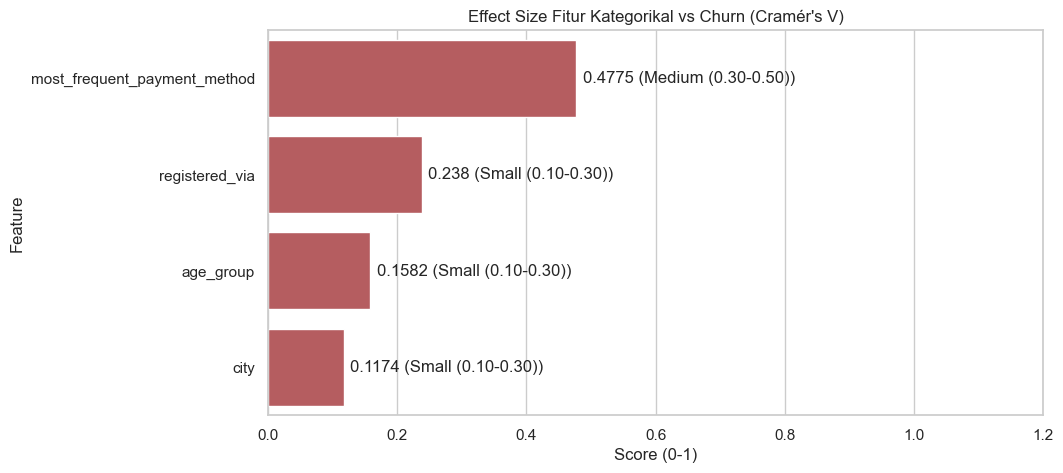

In [4]:
def cramers_v_calculation(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


df_spark = spark.createDataFrame(master_table_pd)

cat_features = ['city', 'age_group', 'registered_via', 'most_frequent_payment_method']
target = 'is_churn'

print("--- Analisis Cramér's V (Hubungan Kategorikal dengan Churn) ---")

results = []

for feature in cat_features:
    ct_spark = df_spark.na.drop(subset=[feature, target]).stat.crosstab(feature, target)
    ct_pd = ct_spark.toPandas()
    first_col = ct_pd.columns[0]
    ct_pd = ct_pd.set_index(first_col)
    
    # Hitung P-Value
    chi2, p, dof, expected = stats.chi2_contingency(ct_pd)
    
    # Hitung Cramér's V
    score = cramers_v_calculation(ct_pd)
    
    if score < 0.10:
        impact = "Negligible (<0.10)"
    elif score < 0.30:
        impact = "Small (0.10-0.30)"
    elif score < 0.50:
        impact = "Medium (0.30-0.50)"
    else:
        impact = "Large (>0.50)"

    results.append({
        'Feature': feature,
        'P-Value': float(p), # Pastikan float python biasa
        'Significant': 'Yes' if p < 0.05 else 'No',
        'Cramers_V': round(score, 4),
        'Impact': impact  
    })

df_cramers = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False)
print(df_cramers)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_cramers, x='Cramers_V', y='Feature', color='#c44e52')

for i in range(len(df_cramers)):
    score = df_cramers.iloc[i]['Cramers_V']
    impact_text = df_cramers.iloc[i]['Impact']
    plt.text(score + 0.01, i, f"{score} ({impact_text})", va='center')

plt.title("Effect Size Fitur Kategorikal vs Churn (Cramér's V)")
plt.xlabel("Score (0-1)")
plt.xlim(0, 1.2) 
plt.show()

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from pyspark.sql import Window
import pyspark.sql.functions as F

df_spark = spark.createDataFrame(master_table_pd)

# Fitur numerik
num_features = [
    'total_transactions', 'total_plan_days', 'total_amount_paid', 
    'avg_amount_paid', 'count_auto_renew', 'count_cancel', 
    'days_since_last_activity', 'total_secs_last_1month', 
    'active_days_last_1month', 'percent_complete_last_1month',
    'total_secs_last_3month', 'active_days_last_3month',
    'lifetime_active_days'
]

results_effect = []

print("--- Analisis Rank-Biserial Correlation ---\n")

for feature in num_features:
    df_clean = df_spark.select(feature, 'is_churn').na.drop()
    
    # Hitung ranking (rank sum)
    # Mann-Whitney butuh ranking dari seluruh data (gabungan churn & loyal)
    window_spec = Window.orderBy(F.col(feature))
    df_ranked = df_clean.withColumn("rank_val", F.rank().over(window_spec))
    
    # Agregasi data (Hitung n dan Sum of Ranks per grup)
    agg_results = df_ranked.groupBy("is_churn").agg(
        F.count("*").alias("n"),
        F.sum("rank_val").alias("sum_rank")
    ).collect()
    
    
    row_churn = next((row for row in agg_results if row['is_churn'] == 1), None)
    row_loyal = next((row for row in agg_results if row['is_churn'] == 0), None)
    
    # Cek jika data lengkap
    if not row_churn or not row_loyal:
        print(f"Skipping {feature}: Data salah satu grup kosong.")
        continue
        
    n1 = row_churn['n']          # Jumlah user Churn
    n2 = row_loyal['n']          # Jumlah user Loyal
    R1 = row_churn['sum_rank']   # Total Rank user Churn
    
    # HITUNG MANN-WHITNEY U
    # Rumus U1 = R1 - (n1 * (n1 + 1)) / 2
    U1 = R1 - (n1 * (n1 + 1)) / 2
    
    # HITUNG RANK-BISERIAL CORRELATION (r)
    # Rumus: r = (2 * U1) / (n1 * n2) - 1
    u_total = n1 * n2
    r = (2 * U1) / u_total - 1
    
    # HITUNG P-VALUE (Z-Approximation)
    # Karena data besar, kita pakai pendekatan distribusi normal (Z-test)
    mu = u_total / 2
    sigma = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
    z_score = (U1 - mu) / sigma
    
    # P-value (Two-sided)
    p_value = stats.norm.sf(abs(z_score)) * 2 
    
    abs_r = abs(r)
    impact = "Negligible/Dapat Diabaikan (<0.1)"
    if abs_r >= 0.5: impact = "Huge (>0.5)"
    elif abs_r >= 0.3: impact = "Medium (0.3-0.5)"
    elif abs_r >= 0.1: impact = "Small (0.1-0.3)"
    
    direction = "Churn Higher" if r > 0 else "Churn Lower"

    results_effect.append({
        'Feature': feature,
        'P-Value': float(p_value),
        'Effect Size (r)': round(r, 4),
        'Magnitude': impact,
        'Direction': direction
    })

# Tampilkan Hasil
df_effect = pd.DataFrame(results_effect)
df_effect['abs_r'] = df_effect['Effect Size (r)'].abs()
df_effect = df_effect.sort_values(by='abs_r', ascending=False).drop(columns=['abs_r'])

print(df_effect)

--- Analisis Rank-Biserial Correlation ---

                         Feature        P-Value  Effect Size (r)  \
4               count_auto_renew   0.000000e+00          -0.7097   
0             total_transactions   0.000000e+00          -0.5399   
5                   count_cancel   0.000000e+00          -0.4553   
8        active_days_last_1month   0.000000e+00          -0.4370   
7         total_secs_last_1month   0.000000e+00          -0.4022   
9   percent_complete_last_1month   0.000000e+00          -0.3853   
3                avg_amount_paid   0.000000e+00           0.3637   
1                total_plan_days   0.000000e+00          -0.1926   
6       days_since_last_activity   0.000000e+00           0.1821   
2              total_amount_paid   0.000000e+00          -0.1783   
11       active_days_last_3month   0.000000e+00          -0.1721   
10        total_secs_last_3month   0.000000e+00          -0.0961   
12          lifetime_active_days  8.523142e-198          -0.0408   

   

## Correlation

Menyiapkan Vector Features...


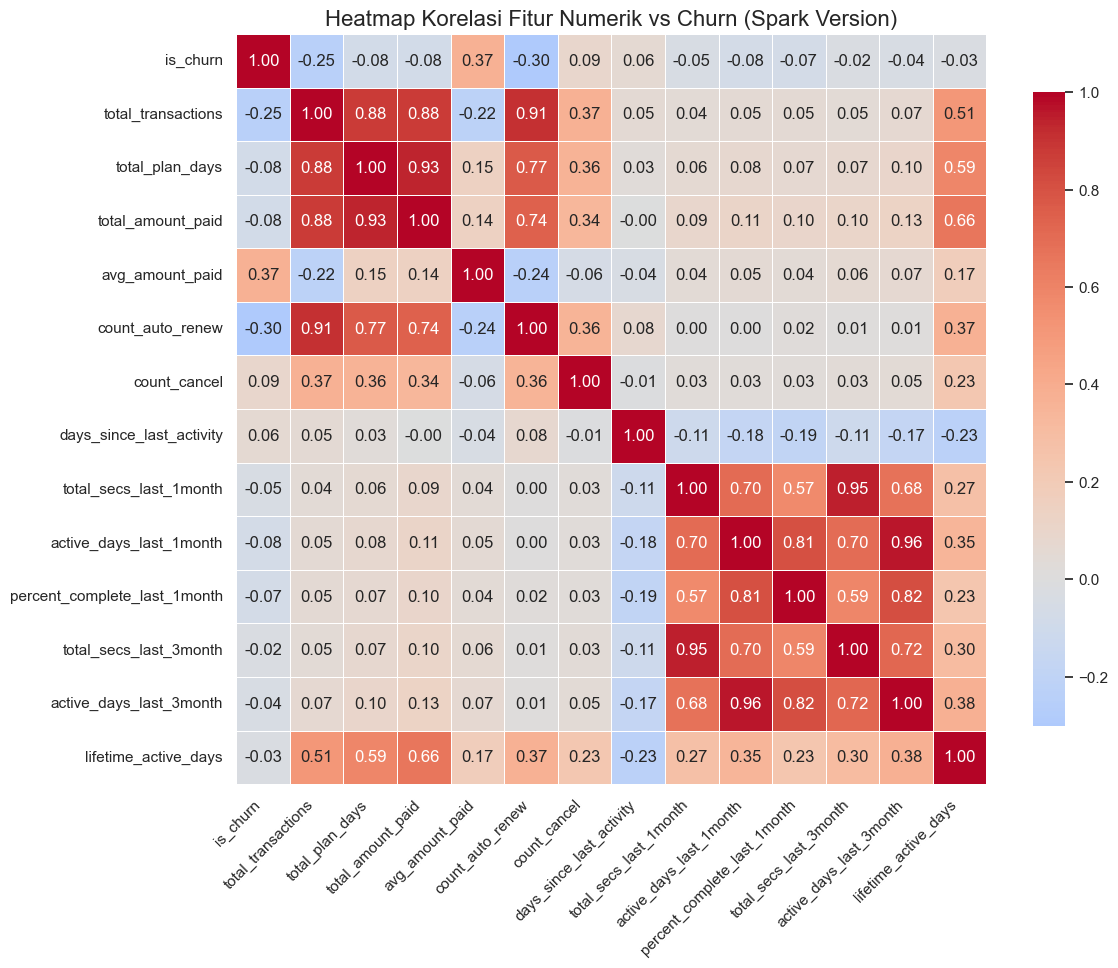

In [6]:
df_spark = spark.createDataFrame(master_table_pd)

numerical_cols = [
    'is_churn', 
    'total_transactions', 'total_plan_days', 'total_amount_paid', 
    'avg_amount_paid', 'count_auto_renew', 'count_cancel', 
    'days_since_last_activity', 'total_secs_last_1month', 
    'active_days_last_1month', 'percent_complete_last_1month',
    'total_secs_last_3month', 'active_days_last_3month',
    'lifetime_active_days'
]

df_clean = df_spark.fillna(0, subset=numerical_cols)
print("Menyiapkan Vector Features...")
assembler = VectorAssembler(
    inputCols=numerical_cols,
    outputCol="corr_features"
)

# Transformasi data
df_vector = assembler.transform(df_clean).select("corr_features")

# Hitung korelasi pakai Pearson
corr_result = Correlation.corr(df_vector, "corr_features", "pearson").head()


corr_matrix_array = corr_result[0].toArray()

# Buat Pandas DataFrame agar bisa dibaca Seaborn
corr_matrix_pd = pd.DataFrame(
    corr_matrix_array, 
    columns=numerical_cols, 
    index=numerical_cols
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix_pd,
    annot=True,        # Tampilkan angka
    fmt=".2f",         # 2 angka di belakang koma
    cmap="coolwarm",   # Biru (Negatif) - Merah (Positif)
    center=0,          # Titik tengah warna di angka 0
    linewidths=.5,
    square=True,      
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap Korelasi Fitur Numerik vs Churn (Spark Version)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()